<a href="https://colab.research.google.com/github/e2458132/-/blob/main/20260624_%E8%A5%BF%E5%B1%B1_%E5%88%86%E6%95%A3%E3%83%BB%E6%A8%99%E6%BA%96%E5%81%8F%E5%B7%AE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 統計学の基礎から学ぶデータサイエンスと機械学習の仕組み


## 🧠 今回カバーする統計学の基礎キーワード
1. **母集団（Population）と標本（Sample）**：データの一部を抜き出す意味
2. **分散（Variance）と標準偏差（Standard Deviation）**：データのバラつき具合
3. **共分散（Covariance）**：2つのデータの関係性
4. **データサイエンス・機械学習との繋がり**：なぜこれを学ぶとAIの原理が解るのか

## 1. サンプルデータの作成（母集団と標本）
研究室全体の実験データ（1000件）を「母集団」とし、そこからランダムに5件だけ抜き出したデータを「標本（サンプル）」と呼びます。
今回は、ある材料の「加熱温度」と「製品強度」の標本データ（10件）を使って計算してみます。

In [ ]:
!pip install japanize-matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

# 10件の実験データ（標本）を作成
study_data = {
    "加熱温度_℃": [100, 120, 140, 160, 180, 200, 220, 240, 260, 280],
    "製品強度_MPa": [45, 52, 58, 63, 70, 72, 80, 85, 83, 92]
}

df = pd.DataFrame(study_data)
print("--- 今回分析する実験データ（標本） ---")
display(df)

--- 今回分析する実験データ（標本） ---


,加熱温度_℃,製品強度_MPa
0,100,45
1,120,52
2,140,58
3,160,63
4,180,70
5,200,72
6,220,80
7,240,85
8,260,83
9,280,92


## 2. 統計量の計算（分散・標準偏差・共分散）
Pandasの機能を使って、データの「バラつき（分散・標準偏差）」と「2つの項目の関係性（共分散）」を全自動で計算します。

In [ ]:
# ① 【分散】データのバラつき具合（平均からの離れ具合の2乗）
# ddof=1 は、母集団から抜き出した「標本」として計算するための統計学上の指定（不偏分散）
variance_temp = df["加熱温度_℃"].var(ddof=1)
variance_strength = df["製品強度_MPa"].var(ddof=1)

# ② 【標準偏差】実際のデータの単位（℃やMPa）に揃えたバラつき（分散にルートをかけたもの）
std_temp = df["加熱温度_℃"].std(ddof=1)
std_strength = df["製品強度_MPa"].std(ddof=1)

# ③ 【共分散】2つのデータが一緒にどう動くか（正なら一緒に上がり、負なら片方が下がる）
# .cov() を使うと、すべての組み合わせの共分散（共分散行列）が計算されます
cov_matrix = df.cov()

print("--- 💡 統計計算の結果 ---")
# 2fとは「出てきた小数の、ドット（.）から下は2桁（2f）だけ表示してね！」という、見た目を整えるための命令。
print(f"【加熱温度】 分散: {variance_temp:.2f} / 標準偏差: {std_temp:.2f}℃")
print(f"【製品強度】 分散: {variance_strength:.2f} / 標準偏差: {std_strength:.2f}MPa")
print(f"\n【共分散行列】（2つの項目の連動関係）:")
display(cov_matrix)

# 行列の表の中から「加熱温度」と「製品強度」が交わる共分散の数値だけをピンポイントで抽出
cov_val = cov_matrix.loc["加熱温度_℃", "製品強度_MPa"]
print(f"➔ 加熱温度と製品強度の共分散 = {cov_val:.2f}")

--- 💡 統計計算の結果 ---
【加熱温度】 分散: 3666.67 / 標準偏差: 60.55℃
【製品強度】 分散: 236.00 / 標準偏差: 15.36MPa

【共分散行列】（2つの項目の連動関係）:


,加熱温度_℃,製品強度_MPa
加熱温度_℃,3666.666667,920.0
製品強度_MPa,920.000000,236.0


➔ 加熱温度と製品強度の共分散 = 920.00


### 💡 統計学の重要ポイント：`ddof=1`（自由度）の指定について

コードの中で `.var(ddof=1)` や `.std(ddof=1)` のように、すべて **`ddof=1`** という指定を行っています。これは統計学において非常に重要な意味を持つ補正処理です。

#### 1. なぜこれが必要なのか？
私たちが実験室で測定して得るデータは、世界中のすべてのデータ（**母集団**）から、一部だけをランダムに抜き出してきたデータ（**標本**）です。

標本データは、どうしても本当の全体（母集団）に比べて**「データの範囲が狭く、平均値の周りに集まりやすい（偏りが出やすい）」**という数学的な性質があります。そのため、補正をせずにそのまま分散を計算すると、本当の全体のバラつきよりも**数値が「小さめ」に計算されてしまうクセ**があります。

#### 2. `ddof=1` がやっていること
この「バラつきを小さく見積もってしまう現象」を解決するために、データの個数（$N$）から「1」を引いた **$N - 1$** で割り算を行うのが `ddof=1`（Delta Degrees of Freedom = 1）の役割です。

* **`ddof=0`（指定なしの標準状態）**：データの個数 $N$ で割る ➔ 手元のデータだけの狭いバラつき（標本分散）
* **`ddof=1`（今回のコード）**：データの個数 $N - 1$ で割る ➔ 分母が小さくなるため、**結果（分散）が少し大きめに補正される**（不偏分散）

#### 3. データサイエンスにおける意味
私たちが本当に知りたいのは、手元の10件のデータだけのバラつきではなく、**「今後の実験全体でデータがどれくらいバラつくか（母集団の分散）」**の予測値です。

Pandasで標本データから全体の統計量を予測するときは、**この `ddof=1` を忘れずにつけることが、データサイエンスにおける正しいデータ処理の作法**になります。

## 3. 可視化とデータサイエンス（機械学習）への繋がり
この統計データ（平均、標準偏差、共分散）を利用して、データサイエンスの基本である「機械学習（単回帰モデル）」の直線をデータに引いてみます。

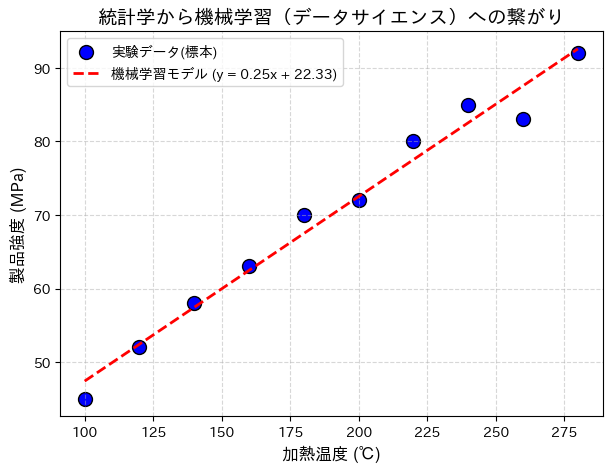

In [ ]:
# グラフの土台のサイズを設定
plt.figure(figsize=(7, 5))

# 1. 実験データの点（散布図）を描画
plt.scatter(df["加熱温度_℃"], df["製品強度_MPa"], color="blue", s=100, label="実験データ(標本)", edgecolor="black")

# 📊 2. 【ここが機械学習の原理！】
# さっき計算した「共分散」を「温度の分散」で割り算するだけで、予測直線の傾きが求まります（最小二乗法) ・slope = 「直線の傾き」という意味
slope = cov_val / variance_temp
# 傾きを使って、直線のスタート地点（切片）を計算 ・intercept = 直線のスタート地点である「切片」という意味
intercept = df["製品強度_MPa"].mean() - slope * df["加熱温度_℃"].mean()

# 3. 予測直線の線を描画
#グラフの横軸の左端（100℃）と右端（280℃）の2つの点だけを np.array([100, 280]) として用意し、それぞれの y の値（製品強度）を計算させて、Matplotlibに「この2つの点を直線で結んで！」と命令している。
x_line = np.array([100, 280]) # x軸の範囲
y_line = slope * x_line + intercept # y = ax + b の計算
plt.plot(x_line, y_line, color="red", linestyle="--", linewidth=2, label=f"機械学習モデル (y = {slope:.2f}x + {intercept:.2f})")

# 4. グラフの装飾（タイトル、軸ラベル、凡例、目盛り線）
plt.title("統計学から機械学習（データサイエンス）への繋がり", fontsize=14)
plt.xlabel("加熱温度 (℃)", fontsize=12)
plt.ylabel("製品強度 (MPa)", fontsize=12)
#plt.legend() を書くことで、その名前札をまとめた分かりやすい説明ボックスがグラフの隅に自動で表示される。
plt.legend() # labelで指定した注釈のボックスを表示
plt.grid(True, linestyle="--", alpha=0.5) # 背景にうっすらグリッド線を表示

# 5. 画像として高画質でColab内保存
image_name = "statistics_to_ml.jpg"
#bbox_inches="tight" は、グラフを画像として保存するときに、**『周りの無駄な余白をカットして、文字がはみ出さないように自動でピタッとトリミングしてくれる命令』**
plt.savefig(image_name, dpi=300, bbox_inches="tight")

# 画面にグラフを表示
plt.show()

## 4. グラフの自動ダウンロード
作成した統計・機械学習のグラフをローカルPCへダウンロードします。

In [ ]:
from google.colab import files
files.download(image_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>